# Notebook 05 — At-Risk Learner Identification

**Project:** Programme Health Intelligence: A Learning Analytics Case Study  
**Dataset:** Open University Learning Analytics Dataset (OULAD)  
**Author:** Megha Sinha  
**Date:** June 2026

---

## Objective

This notebook brings together engagement, assessment, and submission
timing signals from Notebooks 2, 3, and 4 into a unified at-risk
framework, addressing Business Question 5:

*"Which combination of factors is most strongly associated with
withdrawal or failure — and can at-risk students be identified early
enough for intervention to be meaningful?"*

### What We Will Cover
1. Load and merge engagement, assessment, and outcome data
2. Apply individual risk signals — clicks, scores, submission timing
3. Build a combined at-risk score
4. Profile at-risk students by module
5. Validate the framework against actual outcomes
6. Produce a final actionable at-risk framework for operations teams

---

## 1. Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ── Global Style Settings ──────────────────────────────────────────
plt.rcParams.update({
    'font.family':        'DejaVu Sans',
    'font.size':          11,
    'axes.titlesize':     13,
    'axes.titleweight':   'bold',
    'axes.titlepad':      12,
    'axes.labelsize':     11,
    'axes.labelcolor':    '#2C2C2C',
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'xtick.labelsize':    10,
    'ytick.labelsize':    10,
    'legend.fontsize':    10,
    'figure.dpi':         130,
    'savefig.dpi':        150,
    'savefig.bbox':       'tight'
})

sns.set_theme(style='whitegrid', rc={
    'grid.color':     '#E5E5E5',
    'grid.linewidth': 0.7
})

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# ── Business Colour Palette ────────────────────────────────────────
outcome_colours = {
    'Pass':        '#2C5F8A',
    'Distinction': '#1A3A5C',
    'Fail':        '#C0392B',
    'Withdrawn':   '#7F8C8D'
}

risk_colours = {
    'Low Risk':      '#2C5F8A',
    'Medium Risk':   '#F18F01',
    'High Risk':     '#C0392B',
    'Critical Risk': '#7B0D1E'
}

def add_bar_labels(ax, fmt='{:.0f}', padding=2,
                   fontsize=10, color='#2C2C2C'):
    for bar in ax.patches:
        val = bar.get_height()
        if val > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                val + padding,
                fmt.format(val),
                ha='center', va='bottom',
                fontsize=fontsize, color=color,
                fontweight='bold'
            )

print("Global styles and palette loaded successfully")

Global styles and palette loaded successfully


---

## 2. Load Cleaned Data

In [2]:
processed_path = '../data/processed/'

student_info       = pd.read_csv(processed_path + 'studentInfo_clean.csv')
student_vle        = pd.read_csv(processed_path + 'studentVle_sampled.csv')
student_assessment = pd.read_csv(processed_path + 'studentAssessment_clean.csv')
assessments        = pd.read_csv(processed_path + 'assessments_clean.csv')

print("Files loaded successfully\n")
print(f"  student_info:       {student_info.shape[0]:,} rows")
print(f"  student_vle:        {student_vle.shape[0]:,} rows")
print(f"  student_assessment: {student_assessment.shape[0]:,} rows")
print(f"  assessments:        {assessments.shape[0]:,} rows")

Files loaded successfully

  student_info:       32,593 rows
  student_vle:        1,065,529 rows
  student_assessment: 173,739 rows
  assessments:        206 rows


---

## 3. Build Individual Risk Signals

For each student we calculate three independent risk signals
identified in Notebooks 2, 3, and 4:

- **Signal 1 — Engagement:** Total VLE clicks (threshold: 75)
- **Signal 2 — Assessment Score:** Median score across submissions (threshold: 55)
- **Signal 3 — Submission Timing:** Proportion of late submissions

In [3]:
# ── Signal 1 — Engagement ─────────────────────────────────────────
engagement = (
    student_vle
    .groupby(['id_student', 'code_module', 'code_presentation'])['sum_click']
    .sum()
    .reset_index()
    .rename(columns={'sum_click': 'total_clicks'})
)

# ── Signal 2 & 3 — Assessment score and submission timing ─────────
assessment_full = student_assessment.merge(
    assessments[['id_assessment', 'code_module',
                 'code_presentation', 'date', 'weight']],
    on='id_assessment',
    how='left'
)

assessment_full['days_to_deadline'] = (
    assessment_full['date_submitted'] - assessment_full['date']
)
assessment_full['is_late'] = (
    assessment_full['days_to_deadline'] > 0).astype(int)

# Aggregate per student per module
assessment_signals = (
    assessment_full
    .groupby(['id_student', 'code_module', 'code_presentation'])
    .agg(
        median_score=('score', 'median'),
        late_submission_pct=('is_late', 'mean')
    )
    .reset_index()
)
assessment_signals['late_submission_pct'] = (
    assessment_signals['late_submission_pct'] * 100).round(1)

print("=== INDIVIDUAL SIGNALS — SUMMARY ===\n")
print(f"Students with engagement data:   {engagement['id_student'].nunique():,}")
print(f"Students with assessment data:   {assessment_signals['id_student'].nunique():,}")

=== INDIVIDUAL SIGNALS — SUMMARY ===

Students with engagement data:   25,193
Students with assessment data:   23,351


---

## 4. Combine Signals & Build At-Risk Score

Each signal contributes one risk point if it crosses its threshold:
- **+1** if total clicks < 75
- **+1** if median score < 55
- **+1** if late submission % > 30%

Combined score ranges from 0 (no risk flags) to 3 (all flags triggered).
This is mapped to a risk category for operational use.

In [4]:
# Merge all signals with student outcomes
student_signals = student_info[
    ['id_student', 'code_module', 'code_presentation', 'final_result']
].merge(
    engagement,
    on=['id_student', 'code_module', 'code_presentation'],
    how='left'
).merge(
    assessment_signals,
    on=['id_student', 'code_module', 'code_presentation'],
    how='left'
)

# Fill missing engagement with 0 — no VLE activity recorded
student_signals['total_clicks'] = (
    student_signals['total_clicks'].fillna(0))

# ── Apply risk flags ───────────────────────────────────────────────
student_signals['flag_engagement'] = (
    student_signals['total_clicks'] < 75).astype(int)

# Flag missing assessment data as high risk
student_signals['flag_score'] = (
    (student_signals['median_score'] < 55) |
    (student_signals['median_score'].isna())
).astype(int)

student_signals['flag_late'] = (
    (student_signals['late_submission_pct'] > 30) |
    (student_signals['late_submission_pct'].isna())
).astype(int)

# Combined risk score — sum of all flags
student_signals['risk_score'] = (
    student_signals['flag_engagement'] +
    student_signals['flag_score'] +
    student_signals['flag_late']
)

# Map to risk category
risk_map = {
    0: 'Low Risk',
    1: 'Medium Risk',
    2: 'High Risk',
    3: 'Critical Risk'
}
student_signals['risk_category'] = (
    student_signals['risk_score'].map(risk_map))

print("=== RISK SCORE DISTRIBUTION ===\n")
print(student_signals['risk_category'].value_counts())
print(f"\nTotal students assessed: {len(student_signals):,}")

# Save student signals with risk categories for Power BI
student_signals.to_csv(
    processed_path + 'student_signals.csv', index=False)
print("student_signals.csv saved to data/processed/")

=== RISK SCORE DISTRIBUTION ===

Medium Risk      9312
Low Risk         8825
Critical Risk    8105
High Risk        6351
Name: risk_category, dtype: int64

Total students assessed: 32,593
student_signals.csv saved to data/processed/


---

### 4.1 Risk Category vs Final Outcome

Validating the at-risk framework — do higher risk categories
actually predict worse outcomes?

In [5]:
# Outcome distribution by risk category
risk_outcomes = (
    student_signals
    .groupby(['risk_category', 'final_result'])
    .size()
    .unstack(fill_value=0)
    .reindex(index=['Low Risk', 'Medium Risk',
                    'High Risk', 'Critical Risk'],
             columns=['Distinction', 'Pass', 'Fail', 'Withdrawn'],
             fill_value=0)
)

risk_outcomes['total'] = risk_outcomes.sum(axis=1)
risk_outcomes['success_rate'] = (
    (risk_outcomes['Distinction'] + risk_outcomes['Pass']) /
    risk_outcomes['total'] * 100
).round(1)
risk_outcomes['fail_withdrawn_rate'] = (
    (risk_outcomes['Fail'] + risk_outcomes['Withdrawn']) /
    risk_outcomes['total'] * 100
).round(1)

print("=== RISK CATEGORY VS FINAL OUTCOME ===\n")
print(risk_outcomes[['total', 'success_rate', 'fail_withdrawn_rate']])

=== RISK CATEGORY VS FINAL OUTCOME ===

final_result   total  success_rate  fail_withdrawn_rate
risk_category                                          
Low Risk        8825         83.60                16.40
Medium Risk     9312         59.20                40.80
High Risk       6351         37.70                62.30
Critical Risk   8105          1.30                98.70


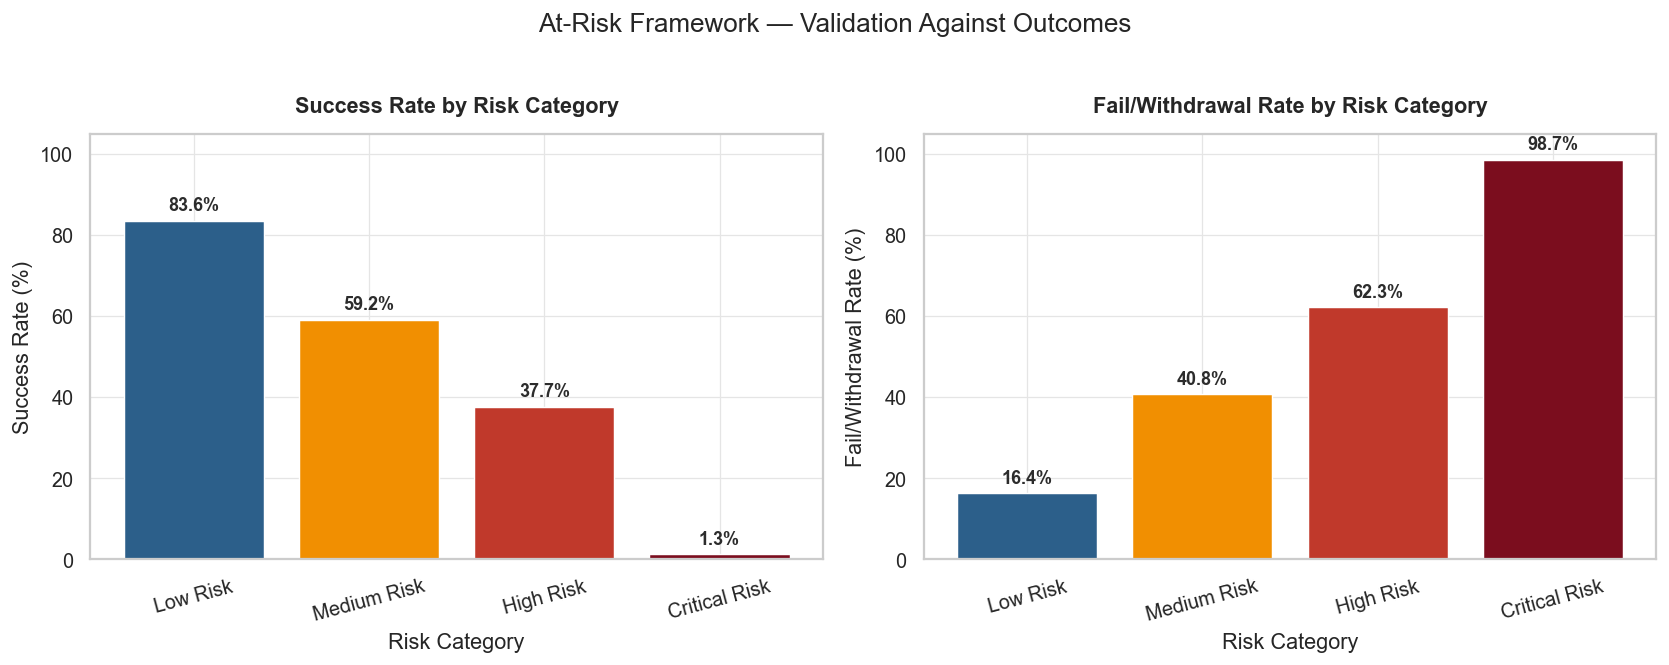

Chart saved to images/


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

risk_order = ['Low Risk', 'Medium Risk', 'High Risk', 'Critical Risk']
colours_list = [risk_colours[r] for r in risk_order]

# Left — success rate by risk category
success_vals = risk_outcomes.loc[risk_order, 'success_rate']
axes[0].bar(risk_order, success_vals,
            color=colours_list, edgecolor='white', linewidth=0.8)
axes[0].set_title('Success Rate by Risk Category')
axes[0].set_xlabel('Risk Category')
axes[0].set_ylabel('Success Rate (%)')
axes[0].set_ylim(0, 105)
axes[0].tick_params(axis='x', rotation=15)
add_bar_labels(axes[0], fmt='{:.1f}%', padding=1.5)

# Right — fail/withdrawn rate by risk category
fail_vals = risk_outcomes.loc[risk_order, 'fail_withdrawn_rate']
axes[1].bar(risk_order, fail_vals,
            color=colours_list, edgecolor='white', linewidth=0.8)
axes[1].set_title('Fail/Withdrawal Rate by Risk Category')
axes[1].set_xlabel('Risk Category')
axes[1].set_ylabel('Fail/Withdrawal Rate (%)')
axes[1].set_ylim(0, 105)
axes[1].tick_params(axis='x', rotation=15)
add_bar_labels(axes[1], fmt='{:.1f}%', padding=1.5)

fig.suptitle('At-Risk Framework — Validation Against Outcomes', y=1.02)
plt.tight_layout()
plt.savefig('../images/12_risk_categories.png')
plt.show()
print("Chart saved to images/")

---

## 5. At-Risk Profile by Module

Which modules have the highest concentration of Critical and High
Risk students — and does this align with withdrawal rates from
Notebook 3?

In [7]:
# Risk category distribution by module
module_risk = (
    student_signals
    .groupby(['code_module', 'risk_category'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=['Low Risk', 'Medium Risk',
                      'High Risk', 'Critical Risk'],
             fill_value=0)
)

module_risk['total'] = module_risk.sum(axis=1)
module_risk['high_critical_pct'] = (
    (module_risk['High Risk'] + module_risk['Critical Risk']) /
    module_risk['total'] * 100
).round(1)

print("=== AT-RISK PROFILE BY MODULE ===\n")
print(module_risk.sort_values('high_critical_pct', ascending=False))

=== AT-RISK PROFILE BY MODULE ===

risk_category  Low Risk  Medium Risk  High Risk  Critical Risk  total  \
code_module                                                             
CCC                   4         1577       1250           1603   4434   
BBB                 676         2265       2912           2056   7909   
DDD                1591         1948       1031           1702   6272   
EEE                1449          595        231            659   2934   
GGG                 572         1223        281            458   2534   
FFF                4245         1428        538           1551   7762   
AAA                 288          276        108             76    748   

risk_category  high_critical_pct  
code_module                       
CCC                        64.30  
BBB                        62.80  
DDD                        43.60  
EEE                        30.30  
GGG                        29.20  
FFF                        26.90  
AAA                        

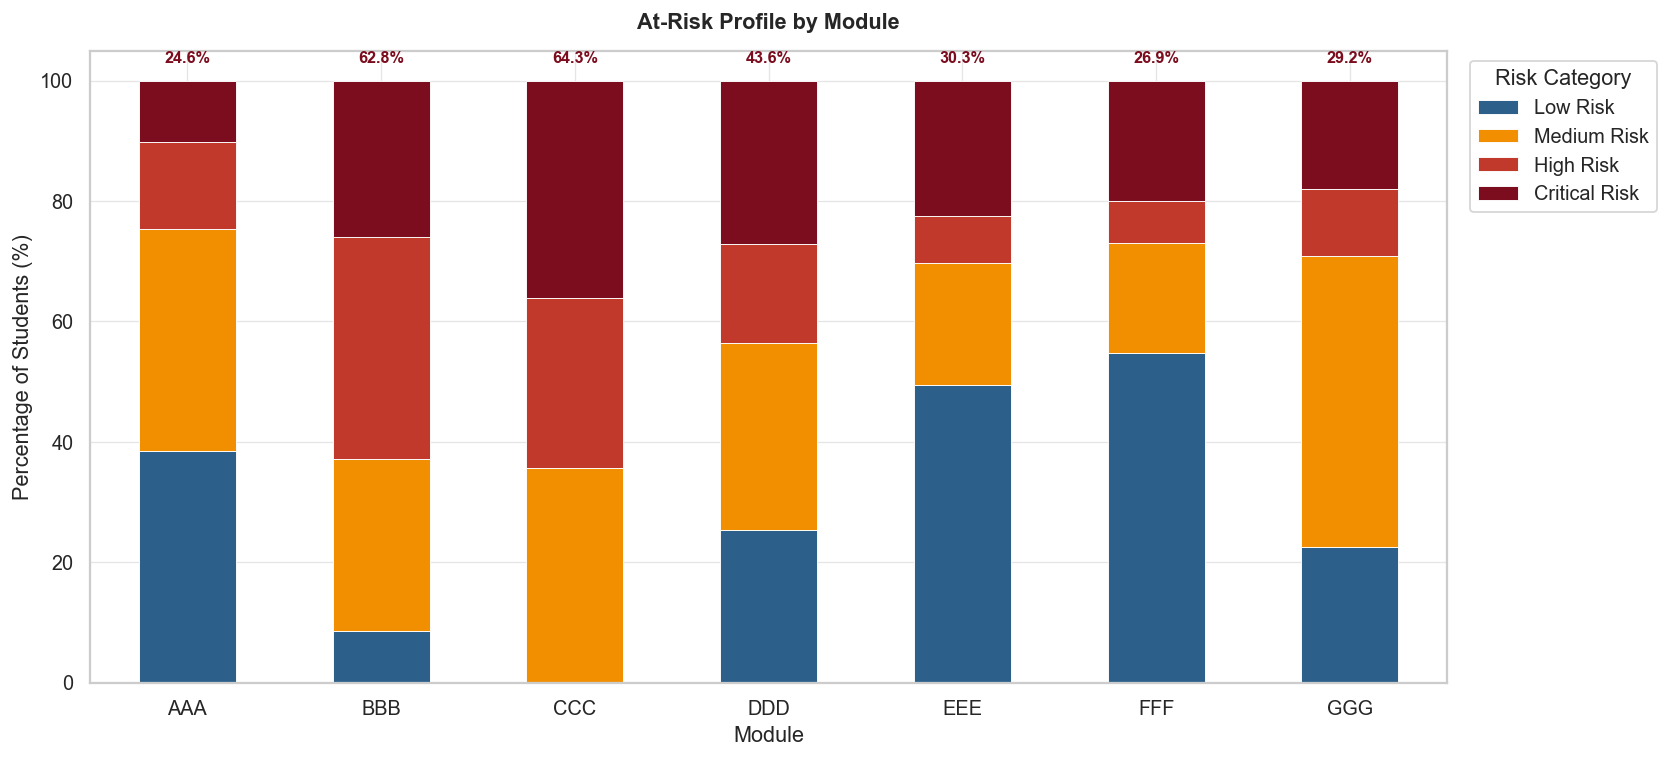

Chart saved to images/


In [8]:
# Stacked bar — risk distribution by module
plot_data = module_risk[['Low Risk', 'Medium Risk',
                          'High Risk', 'Critical Risk']].copy()
plot_pct = plot_data.div(plot_data.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(13, 6))

plot_pct.plot(
    kind='bar',
    stacked=True,
    color=[risk_colours[r] for r in plot_pct.columns],
    ax=ax,
    edgecolor='white',
    linewidth=0.5
)

ax.set_title('At-Risk Profile by Module')
ax.set_xlabel('Module')
ax.set_ylabel('Percentage of Students (%)')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Risk Category',
          bbox_to_anchor=(1.01, 1), loc='upper left')

# Add high/critical % labels above bars
for i, (module, row) in enumerate(module_risk.iterrows()):
    ax.text(i, 103, f"{row['high_critical_pct']}%",
            ha='center', fontsize=9,
            fontweight='bold', color='#7B0D1E')

plt.tight_layout()
plt.savefig('../images/13_risk_by_module.png')
plt.show()
print("Chart saved to images/")

In [11]:
# Build file for Power BI
engagement = (
    student_vle
    .groupby(['id_student', 'code_module', 'code_presentation'])['sum_click']
    .sum()
    .reset_index()
    .rename(columns={'sum_click': 'total_clicks'})
)

assessment_agg = (
    student_assessment
    .merge(
        assessments[['id_assessment', 'code_module',
                     'code_presentation', 'date']],
        on='id_assessment', how='left'
    )
    .assign(is_late=lambda x: (x['date_submitted'] - x['date']) > 0)
    .groupby(['id_student', 'code_module', 'code_presentation'])
    .agg(median_score=('score', 'median'),
         late_submission_pct=('is_late', 'mean'))
    .reset_index()
)

pbi_engagement_assess = student_info[
    ['id_student', 'code_module', 'code_presentation', 'final_result']
].merge(engagement, on=['id_student', 'code_module', 'code_presentation'], how='left'
).merge(assessment_agg, on=['id_student', 'code_module', 'code_presentation'], how='left')

pbi_engagement_assess['total_clicks'] = pbi_engagement_assess['total_clicks'].fillna(0)
pbi_engagement_assess['late_submission_pct'] = (pbi_engagement_assess['late_submission_pct'] * 100).round(1)

pbi_engagement_assess['engagement_band'] = pd.cut(
    pbi_engagement_assess['total_clicks'],
    bins=[0, 25, 75, 150, 300, float('inf')],
    labels=['Very Low (0-25)', 'Low (26-75)',
            'Medium (76-150)', 'High (151-300)', 'Very High (300+)'],
    include_lowest=True
)

pbi_engagement_assess['score_band'] = pd.cut(
    pbi_engagement_assess['median_score'],
    bins=[0, 40, 55, 70, 85, 100],
    labels=['Very Low (0-40)', 'Low (41-55)',
            'Medium (56-70)', 'High (71-85)',
            'Very High (86-100)'],
    include_lowest=True
)

pbi_engagement_assess.to_csv(processed_path + 'pbi_engagement_assessment.csv', index=False)
print(f"pbi_engagement_assessment.csv — {len(pbi_engagement_assess):,} rows saved")

pbi_engagement_assessment.csv — 32,593 rows saved


---

## 6. Final At-Risk Framework — Operational Summary

### Risk Signal Thresholds

| Signal | Threshold | Source |
|---|---|---|
| VLE Engagement | < 75 total clicks | Notebook 02 |
| Assessment Score | < 55 median score | Notebook 04 |
| Submission Timing | > 30% late submissions | Notebook 04 |
| Missing Assessment Data | No submissions recorded | Notebook 03 |

### Risk Categories & Recommended Actions

| Risk Category | Flags | Success Rate | Recommended Action |
|---|---|---|---|
| Low Risk | 0 | 83.6% | Monitor only — no intervention needed |
| Medium Risk | 1 | 59.2% | Light-touch outreach — check-in email or message |
| High Risk | 2 | 37.7% | Active intervention — scheduled 1:1 support session |
| Critical Risk | 3 | 1.3% | Urgent intervention — immediate contact, escalate to programme manager |

### When to Act

| Trigger | Timing | Action |
|---|---|---|
| No VLE activity | By end of week 2 | Outreach email |
| Score below 55 | After first assessment (week 1+) | Academic support referral |
| Late submission pattern | After second late submission | Check-in call |
| No assessment submitted | By assessment deadline | Urgent contact |
| Pre-module withdrawal risk | At enrolment | Pre-module engagement campaign |

### Priority Modules for Intervention

Based on combined findings across Notebooks 1–5:

| Module | Key Issue | Priority |
|---|---|---|
| CCC | Highest overall withdrawal (44.5%) + sustained dropout | Critical |
| BBB | 94.3% pre-assessment dropout + 55.6% very early withdrawal | Critical |
| DDD | High withdrawal (35.9%) + high risk concentration | High |
| FFF | High withdrawal (31%) + largest cohort | High |
| GGG | Lowest risk — benchmark for other modules | Reference |